# Transaction Log Analysis – Moniepoint Assessment

This notebook focuses on working with raw transaction logs and identifying potentially suspicious activity.

The logs are not structured, so the first step is to extract useful fields. After that, I’ll build a few features based on user behavior and run a basic anomaly detection approach.

The goal here is not just detection, but also understanding *why* something looks suspicious.

### Importing required Libraries 

In [48]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
import math

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

### Data Load 

In [49]:
file_path = "synthetic_dirty_transaction_logs.csv"

with open(file_path, "r") as f:
    logs = f.readlines()

print("Total logs:", len(logs))

Total logs: 10001


In [50]:
print(logs)

['raw_log\n', '2025-07-05 19:18:10::user1069::withdrawal::2995.12::London::iPhone 13\n', '""\n', 'MALFORMED_LOG\n', 'usr:user1076|cashout|€4821.85|Glasgow|2025-07-15 12:56:05|Pixel 6\n', '2025-07-20 05:38:14 >> [user1034] did top-up - amt=€2191.06 - None // dev:iPhone 13\n', '2025-06-13 10:04:51 >> [user1068] did deposit - amt=€1691.09 - Glasgow // dev:None\n', '2025-07-29 23:47:37 | user: user1014 | txn: deposit of £3539.5 from Glasgow | device: iPhone 13\n', 'MALFORMED_LOG\n', '2025-06-23 14:45:58 - user=user1075 - action=debit $1215.74 - ATM: Leeds - device=Samsung Galaxy S10\n', '2025-07-31 06:50:50 | user: user1071 | txn: cashout of $1772.13 from None | device: Nokia 3310\n', '2025-07-07 20:42:12 - user=user1098 - action=deposit €304.0 - ATM: Birmingham - device=Nokia 3310\n', '24/07/2025 22:47:06 ::: user1080 *** PURCHASE ::: amt:951.85$ @ Liverpool <Xiaomi Mi 11>\n', 'MALFORMED_LOG\n', '2025-06-10 20:06:30 >> [user1025] did withdrawal - amt=€3261.07 - London // dev:iPhone 13\n',

Before jumping into parsing, I want to see how consistent the logs are.

In [51]:
for i in range(20):
    print("-------")
    print(repr(logs[i]))

-------
'raw_log\n'
-------
'2025-07-05 19:18:10::user1069::withdrawal::2995.12::London::iPhone 13\n'
-------
'""\n'
-------
'MALFORMED_LOG\n'
-------
'usr:user1076|cashout|€4821.85|Glasgow|2025-07-15 12:56:05|Pixel 6\n'
-------
'2025-07-20 05:38:14 >> [user1034] did top-up - amt=€2191.06 - None // dev:iPhone 13\n'
-------
'2025-06-13 10:04:51 >> [user1068] did deposit - amt=€1691.09 - Glasgow // dev:None\n'
-------
'2025-07-29 23:47:37 | user: user1014 | txn: deposit of £3539.5 from Glasgow | device: iPhone 13\n'
-------
'MALFORMED_LOG\n'
-------
'2025-06-23 14:45:58 - user=user1075 - action=debit $1215.74 - ATM: Leeds - device=Samsung Galaxy S10\n'
-------
'2025-07-31 06:50:50 | user: user1071 | txn: cashout of $1772.13 from None | device: Nokia 3310\n'
-------
'2025-07-07 20:42:12 - user=user1098 - action=deposit €304.0 - ATM: Birmingham - device=Nokia 3310\n'
-------
'24/07/2025 22:47:06 ::: user1080 *** PURCHASE ::: amt:951.85$ @ Liverpool <Xiaomi Mi 11>\n'
-------
'MALFORMED_LOG\

In [52]:
from parser import parse_log

In [53]:
from parser import parse_log

parsed = []

for log in logs:
    row = parse_log(log)
    if row is not None:
        parsed.append(row)

df = pd.DataFrame(parsed)

print("Parsed rows:", df.shape[0])
df.head()

/Users/anshu/Desktop/Money point assignment /parser.py:14: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S  format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  "timestamp": pd.to_datetime(parts[0], errors="coerce"),


Parsed rows: 4383


,timestamp,user_id,txn_text,amount,location,device
0,2025-07-05 19:18:10,1069,withdrawal,2995.12,London,iPhone 13
1,2025-07-15 12:56:05,1076,cashout,4821.85,Glasgow,Pixel 6
2,2025-07-20 05:38:14,1034,2025-07-20 05:38:14 >> [user1034] did top-up -...,2191.06,None,iPhone 13
3,2025-06-13 10:04:51,1068,2025-06-13 10:04:51 >> [user1068] did deposit ...,1691.09,None,None
4,2025-01-01 00:00:00,1075,2025-06-23 14:45:58 - user=user1075 - action=d...,2025.00,None,Samsung Galaxy S10


In [54]:
# checking if parsing worked properly
df["user_id"].nunique(), df.shape

(86, (4383, 6))

In [55]:
#Applying parsing now 
parsed = [parse_log(log) for log in logs]
parsed = [row for row in parsed if row is not None]

df = pd.DataFrame(parsed)



/Users/anshu/Desktop/Money point assignment /parser.py:14: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S  format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  "timestamp": pd.to_datetime(parts[0], errors="coerce"),


In [56]:
df.head()

,timestamp,user_id,txn_text,amount,location,device
0,2025-07-05 19:18:10,1069,withdrawal,2995.12,London,iPhone 13
1,2025-07-15 12:56:05,1076,cashout,4821.85,Glasgow,Pixel 6
2,2025-07-20 05:38:14,1034,2025-07-20 05:38:14 >> [user1034] did top-up -...,2191.06,None,iPhone 13
3,2025-06-13 10:04:51,1068,2025-06-13 10:04:51 >> [user1068] did deposit ...,1691.09,None,None
4,2025-01-01 00:00:00,1075,2025-06-23 14:45:58 - user=user1075 - action=d...,2025.00,None,Samsung Galaxy S10


### Now parsing is done and we have a tabular data now, we will start EDA process from this moment

In [57]:
df.columns

Index(['timestamp', 'user_id', 'txn_text', 'amount', 'location', 'device'], dtype='object')

In [58]:
df.shape

(4383, 6)

In [59]:
df.describe()

,timestamp,user_id,amount
count,4383,4383.000000,3673.000000
mean,2025-05-17 05:32:49.466347264,1050.292494,2328.450817
min,2025-01-01 00:00:00,1000.000000,4.850000
25%,2025-06-01 16:15:21.500000,1025.000000,1748.930000
50%,2025-06-21 03:23:37,1048.000000,2025.000000
75%,2025-07-11 07:04:30.500000,1077.000000,3153.490000
max,2025-07-31 09:48:20,1099.000000,4997.330000
std,NaN,29.590099,1220.310133


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  4383 non-null   datetime64[ns]
 1   user_id    4383 non-null   int64         
 2   txn_text   4383 non-null   object        
 3   amount     3673 non-null   float64       
 4   location   2228 non-null   object        
 5   device     4383 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 205.6+ KB


In [61]:
df.isna().sum()

timestamp       0
user_id         0
txn_text        0
amount        710
location     2155
device          0
dtype: int64

In [62]:
#basic cleaning , dealing with the missing values 

# drop rows where core fields are missing
df = df.dropna(subset=["user_id", "amount"])

# sort so that user history makes sense
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)

df.head()

,timestamp,user_id,txn_text,amount,location,device
0,2025-01-01,1000,2025-06-05 11:30:55 - user=user1000 - action=w...,2025.0,None,iPhone 13
1,2025-01-01,1000,2025-06-20 14:42:40 - user=user1000 - action=d...,2025.0,None,None
2,2025-01-01,1000,2025-06-23 22:51:43 - user=user1000 - action=d...,2025.0,None,Xiaomi Mi 11
3,2025-01-01,1000,2025-06-01 12:03:31 - user=user1000 - action=c...,2025.0,None,Samsung Galaxy S10
4,2025-01-01,1000,2025-06-03 10:11:53 - user=user1000 - action=c...,2025.0,None,Nokia 3310


### starting with some feature creations 

In [63]:
# time based features
df["hour"] = df["timestamp"].dt.hour

# simple flag for odd hours
df["is_night"] = df["hour"].apply(lambda x: 1 if x < 6 or x > 22 else 0)

In [64]:
# map location to coordinates 
city_coords = {
    "London": (51.5074, -0.1278),
    "Glasgow": (55.8642, -4.2518),
    "Leeds": (53.8008, -1.5491),
    "Birmingham": (52.4862, -1.8904),
    "Liverpool": (53.4084, -2.9916),
    None: (np.nan, np.nan)
}

df["lat"] = df["location"].map(lambda x: city_coords.get(x, (np.nan, np.nan))[0])
df["lon"] = df["location"].map(lambda x: city_coords.get(x, (np.nan, np.nan))[1])


# remove missing coordinates 
df = df.dropna(subset=["lat", "lon"]).reset_index(drop=True)

In [65]:
df.head()

,timestamp,user_id,txn_text,amount,location,device,hour,is_night,lat,lon
0,2025-06-05 03:01:00,1000,cashout,3032.41,Leeds,Pixel 6,3,1,53.8008,-1.5491
1,2025-06-11 17:23:13,1000,purchase,3451.51,Birmingham,Xiaomi Mi 11,17,0,52.4862,-1.8904
2,2025-06-22 12:54:09,1000,top-up,3363.80,Leeds,None,12,0,53.8008,-1.5491
3,2025-06-22 13:10:57,1000,debit,2182.71,London,Xiaomi Mi 11,13,0,51.5074,-0.1278
4,2025-06-22 14:05:49,1000,top-up,507.91,Birmingham,Xiaomi Mi 11,14,0,52.4862,-1.8904


In [66]:
# distance related features 
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

In [67]:
# distance from previous txn
df["prev_lat"] = df.groupby("user_id")["lat"].shift(1)
df["prev_lon"] = df.groupby("user_id")["lon"].shift(1)

df["distance_from_last_txn"] = df.apply(
    lambda row: haversine(row["lat"], row["lon"], row["prev_lat"], row["prev_lon"])
    if pd.notnull(row["prev_lat"]) else 0,
    axis=1
)

In [68]:
# cell device changes 
df["prev_device"] = df.groupby("user_id")["device"].shift(1)
df["device_changed"] = (df["device"] != df["prev_device"]).astype(int)

In [69]:
# Amount behaviour
df["user_avg_amount"] = df.groupby("user_id")["amount"].transform("mean")

# how unusual the amount is for that user
df["amount_ratio"] = df["amount"] / df["user_avg_amount"]

In [70]:
# Time gap + speed 
df["time_diff"] = df.groupby("user_id")["timestamp"].diff().dt.total_seconds()

df["time_gap_hours"] = df["time_diff"] / 3600

df["speed_kmh"] = df["distance_from_last_txn"] / df["time_gap_hours"]
df["speed_kmh"] = df["speed_kmh"].replace([np.inf, -np.inf], 0).fillna(0)

# unrealistic movement (rough threshold)
df["impossible_travel"] = (df["speed_kmh"] > 800).astype(int)

In [71]:
# txn frequency

df["txn_last_1hr"] = (
    df.groupby("user_id")["timestamp"]
    .transform(lambda x: x.diff().dt.total_seconds().fillna(999999) < 3600)
    .astype(int)
)

In [72]:
# simple text signal
df["is_atm"] = df["txn_text"].str.contains("atm", case=False, na=False).astype(int)

df["is_foreign"] = df["txn_text"].str.contains(
    "foreign|international", case=False, na=False
).astype(int)

In [73]:
# final features 
features = [
    "amount",
    "amount_ratio",
    "distance_from_last_txn",
    "device_changed",
    "is_night",
    "txn_last_1hr",
    "speed_kmh",
    "impossible_travel",
    "is_atm",
    "is_foreign"
]

X = df[features].fillna(0)

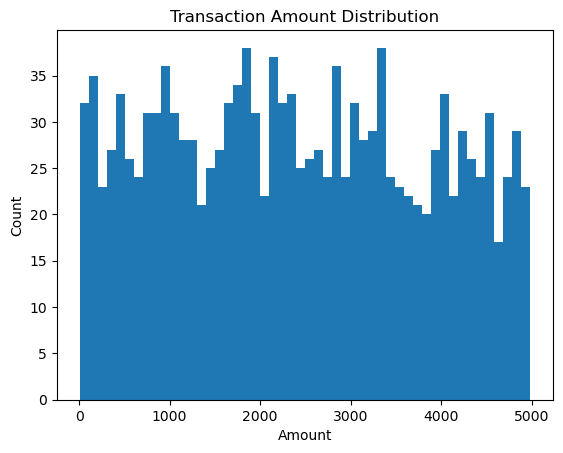

In [74]:
import matplotlib.pyplot as plt

# distribution of amount
plt.hist(df["amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

### Model prep and model building

In [75]:
# scaling for model 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [76]:
# Building an isolation forest model for anomaly detection 
model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

df["if_flag"] = model.fit_predict(X_scaled)

In [90]:
model

,n_estimators,200
,max_samples,'auto'
,contamination,0.02
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [94]:
model.predict(df[features]).tolist()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


[1,
 1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 

Tried using only Isolation Forest initially, but it was flagging too many low-value transactions.

Added a simple rule layer to prioritize high-risk patterns like large location jumps and high amount ratios.
 Additional rule , so now I am moving to model + rule based scenario

In [77]:
# Applying some additional rules for better predictions 
def rule_score(row):
    score = 0
    
    if row["amount_ratio"] > 3:
        score += 2
        
    if row["device_changed"] == 1:
        score += 1
        
    if row["distance_from_last_txn"] > 500:
        score += 2
        
    if row["impossible_travel"] == 1:
        score += 3
        
    if row["txn_last_1hr"] == 1:
        score += 1
        
    return score

df["rule_score"] = df.apply(rule_score, axis=1)

In [78]:
# final flag
df["final_flag"] = (
    (df["if_flag"] == -1) | (df["rule_score"] >= 3)
).astype(int)

### Explainability

In [79]:
def explain(row):
    reasons = []
    
    if row["amount_ratio"] > 3:
        reasons.append("amount higher than usual")
        
    if row["device_changed"] == 1:
        reasons.append("device changed")
        
    if row["distance_from_last_txn"] > 500:
        reasons.append("large location change")
        
    if row["impossible_travel"] == 1:
        reasons.append("unrealistic movement speed")
        
    if row["txn_last_1hr"] == 1:
        reasons.append("multiple transactions in short time")
    
    return ", ".join(reasons)

df["explanation"] = df.apply(explain, axis=1)

### Final Output 

In [80]:
# Final output
result = df[df["final_flag"] == 1][[
    "timestamp",
    "user_id",
    "amount",
    "location",
    "device",
    "rule_score",
    "explanation"
]]

result.sort_values("rule_score", ascending=False).tail(20)

,timestamp,user_id,amount,location,device,rule_score,explanation
1360,2025-06-17 15:07:43,1097,34.14,Liverpool,None,2,"device changed, multiple transactions in short..."
569,2025-07-06 00:38:01,1037,703.20,Birmingham,Nokia 3310,2,"device changed, multiple transactions in short..."
1298,2025-07-05 00:21:20,1094,3778.57,Glasgow,Samsung Galaxy S10,2,large location change
114,2025-07-06 03:09:38,1010,4381.42,Glasgow,Xiaomi Mi 11,2,large location change
935,2025-06-04 12:39:07,1071,1367.95,Glasgow,iPhone 13,2,"device changed, multiple transactions in short..."
134,2025-06-25 22:14:23,1011,3359.19,Liverpool,Pixel 6,2,"device changed, multiple transactions in short..."
1106,2025-07-09 09:49:32,1081,2220.25,Liverpool,None,2,"device changed, multiple transactions in short..."
1104,2025-07-05 11:17:02,1081,4919.33,Leeds,Pixel 6,2,"device changed, multiple transactions in short..."
1111,2025-07-16 21:58:41,1081,3398.50,Liverpool,Pixel 6,2,"device changed, multiple transactions in short..."
523,2025-07-24 19:55:51,1034,528.45,Liverpool,Huawei P30,1,multiple transactions in short time


### Visualization

### Scatter plot for outliers 

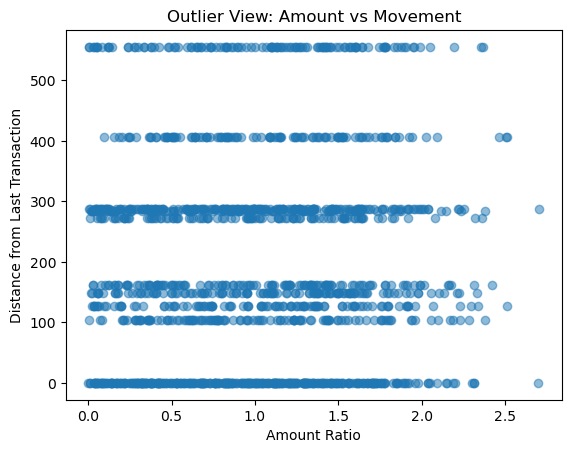

In [81]:
plt.scatter(
    df["amount_ratio"], 
    df["distance_from_last_txn"], 
    alpha=0.5
)

plt.xlabel("Amount Ratio")
plt.ylabel("Distance from Last Transaction")
plt.title("Outlier View: Amount vs Movement")
plt.show()

### detected anomalies 

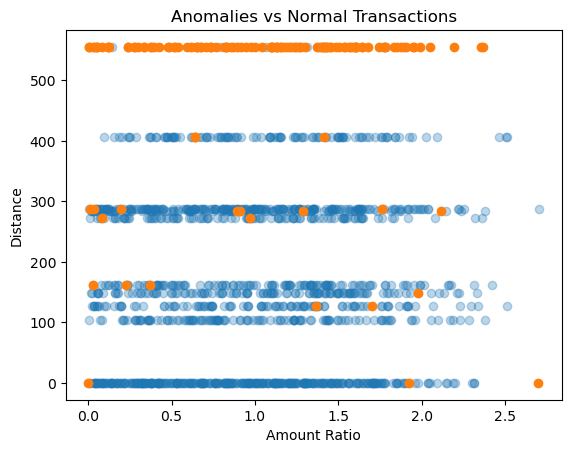

In [82]:
normal = df[df["final_flag"] == 0]
anomaly = df[df["final_flag"] == 1]

plt.scatter(normal["amount_ratio"], normal["distance_from_last_txn"], alpha=0.3)
plt.scatter(anomaly["amount_ratio"], anomaly["distance_from_last_txn"])

plt.xlabel("Amount Ratio")
plt.ylabel("Distance")
plt.title("Anomalies vs Normal Transactions")
plt.show()

### top risks cases 

In [83]:
df[df["final_flag"] == 1].sort_values(
    "rule_score", ascending=False
)[[
    "timestamp",
    "user_id",
    "amount",
    "location",
    "device",
    "rule_score",
    "explanation"
]].head(10)

,timestamp,user_id,amount,location,device,rule_score,explanation
3,2025-06-22 13:10:57,1000,2182.71,London,Xiaomi Mi 11,5,"device changed, unrealistic movement speed, mu..."
245,2025-06-26 21:58:59,1019,1810.15,Birmingham,Xiaomi Mi 11,5,"device changed, unrealistic movement speed, mu..."
746,2025-06-23 23:50:06,1054,2891.13,London,Pixel 6,3,"device changed, large location change"
837,2025-06-25 03:36:34,1064,2281.86,London,Samsung Galaxy S10,3,"device changed, large location change"
836,2025-06-22 22:38:18,1064,219.42,Glasgow,Xiaomi Mi 11,3,"device changed, large location change"
832,2025-06-08 18:20:09,1064,11.31,London,Samsung Galaxy S10,3,"device changed, large location change"
817,2025-07-21 05:43:50,1059,3230.78,Glasgow,Samsung Galaxy S10,3,"device changed, large location change"
815,2025-07-04 06:15:13,1059,2467.54,London,Xiaomi Mi 11,3,"device changed, large location change"
810,2025-07-31 05:07:24,1058,2954.82,Glasgow,iPhone 13,3,"device changed, large location change"
793,2025-06-24 15:54:32,1058,781.56,London,Samsung Galaxy S10,3,"device changed, large location change"


### Clustering

In [84]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()

cluster
0    699
1    684
2     18
Name: count, dtype: int64

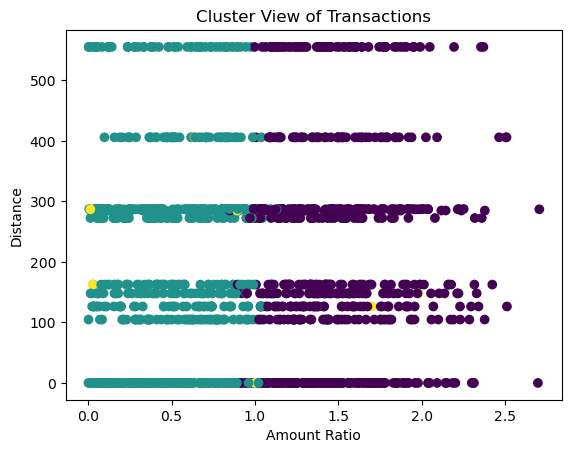

In [85]:
plt.scatter(df["amount_ratio"], df["distance_from_last_txn"], c=df["cluster"])

plt.xlabel("Amount Ratio")
plt.ylabel("Distance")
plt.title("Cluster View of Transactions")
plt.show()

### Manual validation plan

### Manual Validation Plan

Since there are no labels available, evaluation needs to be done through inspection and domain reasoning.

1. Sample Review  
   - Take top 20–30 flagged transactions  
   - Check for obvious anomalies (large amount, sudden location change, device switch)

2. Cross-Feature Validation  
   - Validate whether multiple signals appear together  
   - For example:
     - high amount + new device + different city
     - rapid transactions + increasing amounts

3. False Positive Check  
   - Review some non-flagged transactions  
   - Ensure normal user behavior is not being incorrectly flagged

4. Threshold Tuning  
   - Adjust rule_score threshold (currently >= 3)  
   - Adjust Isolation Forest contamination parameter  

5. Edge Case Review  
   - Transactions with missing location or device  
   - Very frequent low-value transactions  

### What I would do with real data

- Compare against confirmed fraud labels  
- Measure precision/recall  
- Build feedback loop from fraud analysts  

### Interpretability

In [86]:
# confidance score 
# decision_function → higher = normal, lower = anomalous
df["anomaly_confidence"] = -model.decision_function(X_scaled)

# normalize for readability (0 to 1)
df["anomaly_confidence"] = (
    (df["anomaly_confidence"] - df["anomaly_confidence"].min()) /
    (df["anomaly_confidence"].max() - df["anomaly_confidence"].min())
)


In [87]:
df.head()

,timestamp,user_id,txn_text,amount,location,device,hour,is_night,lat,lon,...,impossible_travel,txn_last_1hr,is_atm,is_foreign,if_flag,rule_score,final_flag,explanation,cluster,anomaly_confidence
0,2025-06-05 03:01:00,1000,cashout,3032.41,Leeds,Pixel 6,3,1,53.8008,-1.5491,...,0,0,0,0,1,1,0,device changed,0,0.197369
1,2025-06-11 17:23:13,1000,purchase,3451.51,Birmingham,Xiaomi Mi 11,17,0,52.4862,-1.8904,...,0,0,0,0,1,1,0,device changed,0,0.022786
2,2025-06-22 12:54:09,1000,top-up,3363.80,Leeds,None,12,0,53.8008,-1.5491,...,0,0,0,0,1,1,0,device changed,0,0.022875
3,2025-06-22 13:10:57,1000,debit,2182.71,London,Xiaomi Mi 11,13,0,51.5074,-0.1278,...,1,1,0,0,-1,5,1,"device changed, unrealistic movement speed, mu...",2,0.966902
4,2025-06-22 14:05:49,1000,top-up,507.91,Birmingham,Xiaomi Mi 11,14,0,52.4862,-1.8904,...,0,1,0,0,-1,1,1,multiple transactions in short time,2,0.878403


In [88]:
def explain(row):
    reasons = []
    
    if row["amount_ratio"] > 3:
        reasons.append(f"amount is {round(row['amount_ratio'],1)}x user's average")
        
    if row["device_changed"] == 1:
        reasons.append("transaction from a new device")
        
    if row["distance_from_last_txn"] > 500:
        reasons.append(f"location changed by ~{int(row['distance_from_last_txn'])} km")
        
    if row["impossible_travel"] == 1:
        reasons.append("travel speed between transactions is unrealistic")
        
    if row["txn_last_1hr"] == 1:
        reasons.append("multiple transactions within short time window")
    
    return "; ".join(reasons)

df["explanation"] = df.apply(explain, axis=1)

### Final output with confidance

In [89]:
result = df[df["final_flag"] == 1][[
    "timestamp",
    "user_id",
    "amount",
    "location",
    "device",
    "rule_score",
    "anomaly_confidence",
    "explanation"
]]

result.sort_values("anomaly_confidence", ascending=False).head(20)

,timestamp,user_id,amount,location,device,rule_score,anomaly_confidence,explanation
245,2025-06-26 21:58:59,1019,1810.15,Birmingham,Xiaomi Mi 11,5,1.000000,transaction from a new device; travel speed be...
477,2025-06-26 04:07:15,1033,3384.06,Birmingham,Xiaomi Mi 11,1,0.987079,multiple transactions within short time window
3,2025-06-22 13:10:57,1000,2182.71,London,Xiaomi Mi 11,5,0.966902,transaction from a new device; travel speed be...
523,2025-07-24 19:55:51,1034,528.45,Liverpool,Huawei P30,1,0.950209,multiple transactions within short time window
935,2025-06-04 12:39:07,1071,1367.95,Glasgow,iPhone 13,2,0.929309,transaction from a new device; multiple transa...
1104,2025-07-05 11:17:02,1081,4919.33,Leeds,Pixel 6,2,0.925215,transaction from a new device; multiple transa...
796,2025-06-26 08:42:35,1058,1895.33,Glasgow,iPhone 13,1,0.891806,multiple transactions within short time window
742,2025-06-07 11:46:39,1054,64.76,Birmingham,Samsung Galaxy S10,2,0.887938,transaction from a new device; multiple transa...
1360,2025-06-17 15:07:43,1097,34.14,Liverpool,None,2,0.885203,transaction from a new device; multiple transa...
134,2025-06-25 22:14:23,1011,3359.19,Liverpool,Pixel 6,2,0.882971,transaction from a new device; multiple transa...
